# Coocurrence of cell types on neighbouring channels

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
from functions_plotting import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import seaborn as sns
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

## Parmeters

In [3]:
with open("/CSNG/studekat/ripple_band_project/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

with open("/CSNG/studekat/ripple_band_project/code/params_plotting.yml") as f:
    params_plot = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_band_project/dataframes' ### here the resulting dataframes will be saved
MONKEY_LIST = ['L','N','F'] 
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_plot['colors_class']
CLASS_NAMES = params_analysis['classes_names']

AREA = 'V12'  # in newer files as V1

In [4]:
LAYOUTS = params_plot['layout']

In [5]:
# creating the paired classes names
all_pairs = list(itertools.combinations(FINAL_CLASSES, 2))
pairs_merged = ["+".join(sorted(t)) for t in all_pairs]
for cl in FINAL_CLASSES:
    pairs_merged.append("+".join((cl,cl)))

## Data loading

In [6]:
with open(f'{DF_FOLDER}/dict_pair_occur/all_pairs_count', 'rb') as f:
    all_sums = pickle.load(f)

with open(f'{DF_FOLDER}/dict_pair_occur/close_pairs_count', 'rb') as f:
    close_sums = pickle.load(f)

with open(f'{DF_FOLDER}/dict_pair_occur/classes_counter', 'rb') as f:
    classes_counter = pickle.load(f)

with open(f'{DF_FOLDER}/dict_pair_occur/pooled_count', 'rb') as f:
    pooled_count = pickle.load(f)

## All population pooled 

### Whole population, same widths 

In [7]:
ratio_all_pool = {cl: (close_sums[cl] / pooled_count[cl] if close_sums[cl] != 0 else 0) for cl in pooled_count.keys()}
ratio_all_pool = {tuple(k.split("+")): v for k, v in ratio_all_pool.items()}

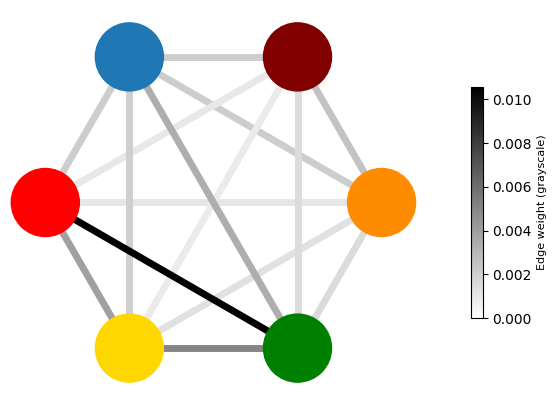

In [8]:
fig, ax = plt.subplots(figsize=(7,5))

data = ratio_all_pool

# Create graph
G = nx.Graph()
for (u, v), w in data.items():
    G.add_edge(u, v, weight=w)
    
# Assume G is already created with your weighted edges
nodes = list(G.nodes())   # get all nodes from the graph
n = len(nodes)

# Place nodes evenly around a circle (hexagon if n=6)
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
radius = 0.1
pos = {node: (radius*np.cos(angle), radius*np.sin(angle)) for node, angle in zip(nodes, angles)}

# Build color list for nodes in order
node_colors = [CLASS_COLORS.get(node, 'gray') for node in G.nodes()]

# Get weights of edges
SCALE = 1500
weights = [d['weight']*SCALE for _, _, d in G.edges(data=True)]
weights_probab = [d['weight'] for _, _, d in G.edges(data=True)]
edge_labels = {edge: f"{w:.2f}" for edge, w in nx.get_edge_attributes(G, 'weight').items()}

# coloring edges
max_w = max(weights) if weights else 1
VMAX = max_w
norm_weights = [w / VMAX for w in weights]  # mapping weights between 0 and 1 to cover the CMAP
cmap = plt.cm.binary
edge_colors = [cmap(w) for w in norm_weights]

# Draw graph
nx.draw(G, pos, with_labels=False, node_color=node_colors,
        node_size=2400, font_size=8, width=5,edge_color=edge_colors,ax=ax,)

#nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

# Create a ScalarMappable for the colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=np.max(weights_probab)))
sm.set_array([])

# Add colorbar next to the graph
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Edge weight (grayscale)", fontsize=8)

plt.axis("equal")
plt.show()


### Non-random edges in solid

In [9]:
# threshold choice aux. calculation
min_key = min(pooled_count, key=pooled_count.get)
min_value = pooled_count[min_key]
print(min_value)

4163


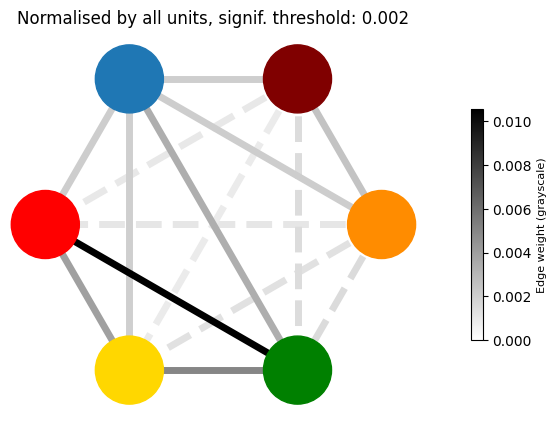

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import numpy as np

fig, ax = plt.subplots(figsize=(7,5))

data = ratio_all_pool

# Create graph
G = nx.Graph()
for (u, v), w in data.items():
    G.add_edge(u, v, weight=w)
    
# Nodes and layout
nodes = list(G.nodes())
n = len(nodes)
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
radius = 0.1
pos = {node: (radius*np.cos(angle), radius*np.sin(angle)) for node, angle in zip(nodes, angles)}

# Node colors
node_colors = [CLASS_COLORS.get(node, 'gray') for node in G.nodes()]

# Edge weights
SCALE = 1500
weights = [d['weight']*SCALE for _, _, d in G.edges(data=True)]
weights_probab = [d['weight'] for _, _, d in G.edges(data=True)]
edge_labels = {edge: f"{w:.2f}" for edge, w in nx.get_edge_attributes(G, 'weight').items()}

WEIGHT_TH = np.round(9/min_value,3)
# Edge coloring
max_w = max(weights) if weights else 1
VMAX = max_w
norm_weights = np.array([w / VMAX for w in weights])
cmap = plt.cm.binary
edge_colors = [cmap(w) for w in norm_weights]

# Split edges by weight threshold
low_weight_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < WEIGHT_TH]
high_weight_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= WEIGHT_TH]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2400, ax=ax)
#nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

# Draw low-weight edges (dashed)
nx.draw_networkx_edges(
    G, pos, edgelist=low_weight_edges,
    edge_color=[edge_colors[i] for i, e in enumerate(G.edges()) if e in low_weight_edges],
    width=5, style="dashed", ax=ax
)
# Draw high-weight edges (solid)
nx.draw_networkx_edges(
    G, pos, edgelist=high_weight_edges,
    edge_color=[edge_colors[i] for i, e in enumerate(G.edges()) if e in high_weight_edges],
    width=5, style="solid", ax=ax
)

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=np.max(weights_probab)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Edge weight (grayscale)", fontsize=8)

for sp in ['right','left','top','bottom']:
    ax.spines[sp].set_visible(False)

ax.set_title(f'Normalised by all units, signif. threshold: {WEIGHT_TH}')

plt.axis("equal")
plt.show()